# Fe(110) surface — spin-resolved spectral function

The **surface** electronic structure of semi-infinite bcc Fe cleaved on (110), from a Wannier tight-binding model by **Lopez-Sancho/Rubio Green's-function decimation** (`analysis.surface`). The semi-infinite bulk below the surface is *downfolded* exactly into a self-energy, so the spectral map shows surface states **plus** the surface-projected bulk continuum.

Fe has spin-orbit coupling here (spinor MLWFs), so we resolve the surface weight into **majority / minority** channels along the magnetization (`z`) using the `.spn` spin operator.

This surface has real experimental/theoretical history: Kim, Vescovo, Heinze & Blügel, *Surface electronic structure of Fe(110): the importance of surface resonances*, Surf. Sci. **478**, 193 (2001), combine spin- and angle-resolved photoemission with first-principles **slab** calculations of Fe(110) and identify several of its d-derived surface states as surface *resonances* rather than true (gap-localized) surface states -- a distinction this notebook's `A_bulk` vs `A_surface` decomposition (bulk-projected vs top-layer spectral weight) makes directly visible, unlike a finite slab.

Self-contained: runs its own converged noncollinear+SOC DFT (same recipe as `w90tutorial/17_iron_soc_spin_texture`, bcc Fe, PseudoDojo fully-relativistic pseudo, 4×4×4, 28→18 spinor MLWFs), no precomputed fixture.

### 1. Converged noncollinear+SOC DFT, Wannierisation, and the spin operator S(R)
`ecutwfc = 60` Ry, 16×16×16 SCF; the Wannier overlaps and `.spn` spin operator are built on a 4×4×4 mesh (the SCF is the slow step, a few minutes).

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


In [2]:
from ase.build import bulk
import torch
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.analysis.spin_texture import spin_operator_r
from waw.analysis.surface import surface_spectral_function

atoms = bulk('Fe', 'bcc', a=2.8699)          # 5.4235 bohr
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'fe'

SOC = dict(noncolin=True, lspinorb=True)
SOC['starting_magnetization(1)'] = 0.4
SOC.update(occupations='smearing', smearing='cold', degauss=0.02)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'fe',
    ecutwfc=60, scf_kpts=(16, 16, 16), nbnd=36, num_wann=18,
    exclude_bands=list(range(1, 9)),   # 8 semicore 3s3p spinor bands
    scdm_entanglement='erfc', scdm_mu=25.0, scdm_sigma=5.0,
    system_extra=SOC, pseudopotentials={'Fe': 'Fe-sp_r.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, write_spn=True,
    rerun_scf=False,          # reuse a completed SCF in runs/fe/ if present
)

result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=18,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8),
    n_restarts=2, dis_n_iter=1000, n_iter=3000, verbose=False,
)
real_lattice_ = real_lattice(atoms)
E_FERMI = ov['fermi_energy']
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2  '
      f'(18 spinor MLWFs); E_F = {E_FERMI:.3f} eV')

W = torch.bmm(result.dis.V, result.spread.U_final)      # full spinor gauge V·U
SS_R = spin_operator_r(W, ov['spn'], result.wdata.kpts, MP_GRID, real_lattice_)

Omega_I = 9.3225 Ang^2  (18 spinor MLWFs); E_F = 17.630 eV


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the deviation printed on the
Wannierization mesh is the quantitative form of the same statement.

In [ ]:
from waw.interfaces.ase.structure import band_path
from waw.analysis.elph import band_eigensystem
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=150)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = band_eigensystem(result.hr, bp.kpts)[0] * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'fe', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Fe(110): DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(8.0, 19.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Surface spectral function A(k∥, E), spin-resolved
along a cut of the (110) surface Brillouin zone (Γ̄ → edge). `spin_op_r` switches on the majority/minority decomposition; the bulk `H(R)` is re-indexed into principal layers along the surface normal.

In [4]:
miller = (1, 1, 0)                              # primitive-cell Miller index
NK = 120
kpath = np.stack([np.linspace(0, 0.5, NK), np.zeros(NK)], axis=1)
energies = np.linspace(11.0, 19.0, 240) * EV_TO_HARTREE   # around the d-bands

sf = surface_spectral_function(result.hr, real_lattice_, miller, kpath,
                               energies, eta=0.03 * EV_TO_HARTREE,
                               spin_op_r=SS_R, spin_axis=(0, 0, 1))
print('A_up + A_dn == A_surface:',
      np.allclose(sf.A_up + sf.A_dn, sf.A_surface, atol=1e-9))

A_up + A_dn == A_surface: True


### 3. Majority vs minority surface bands

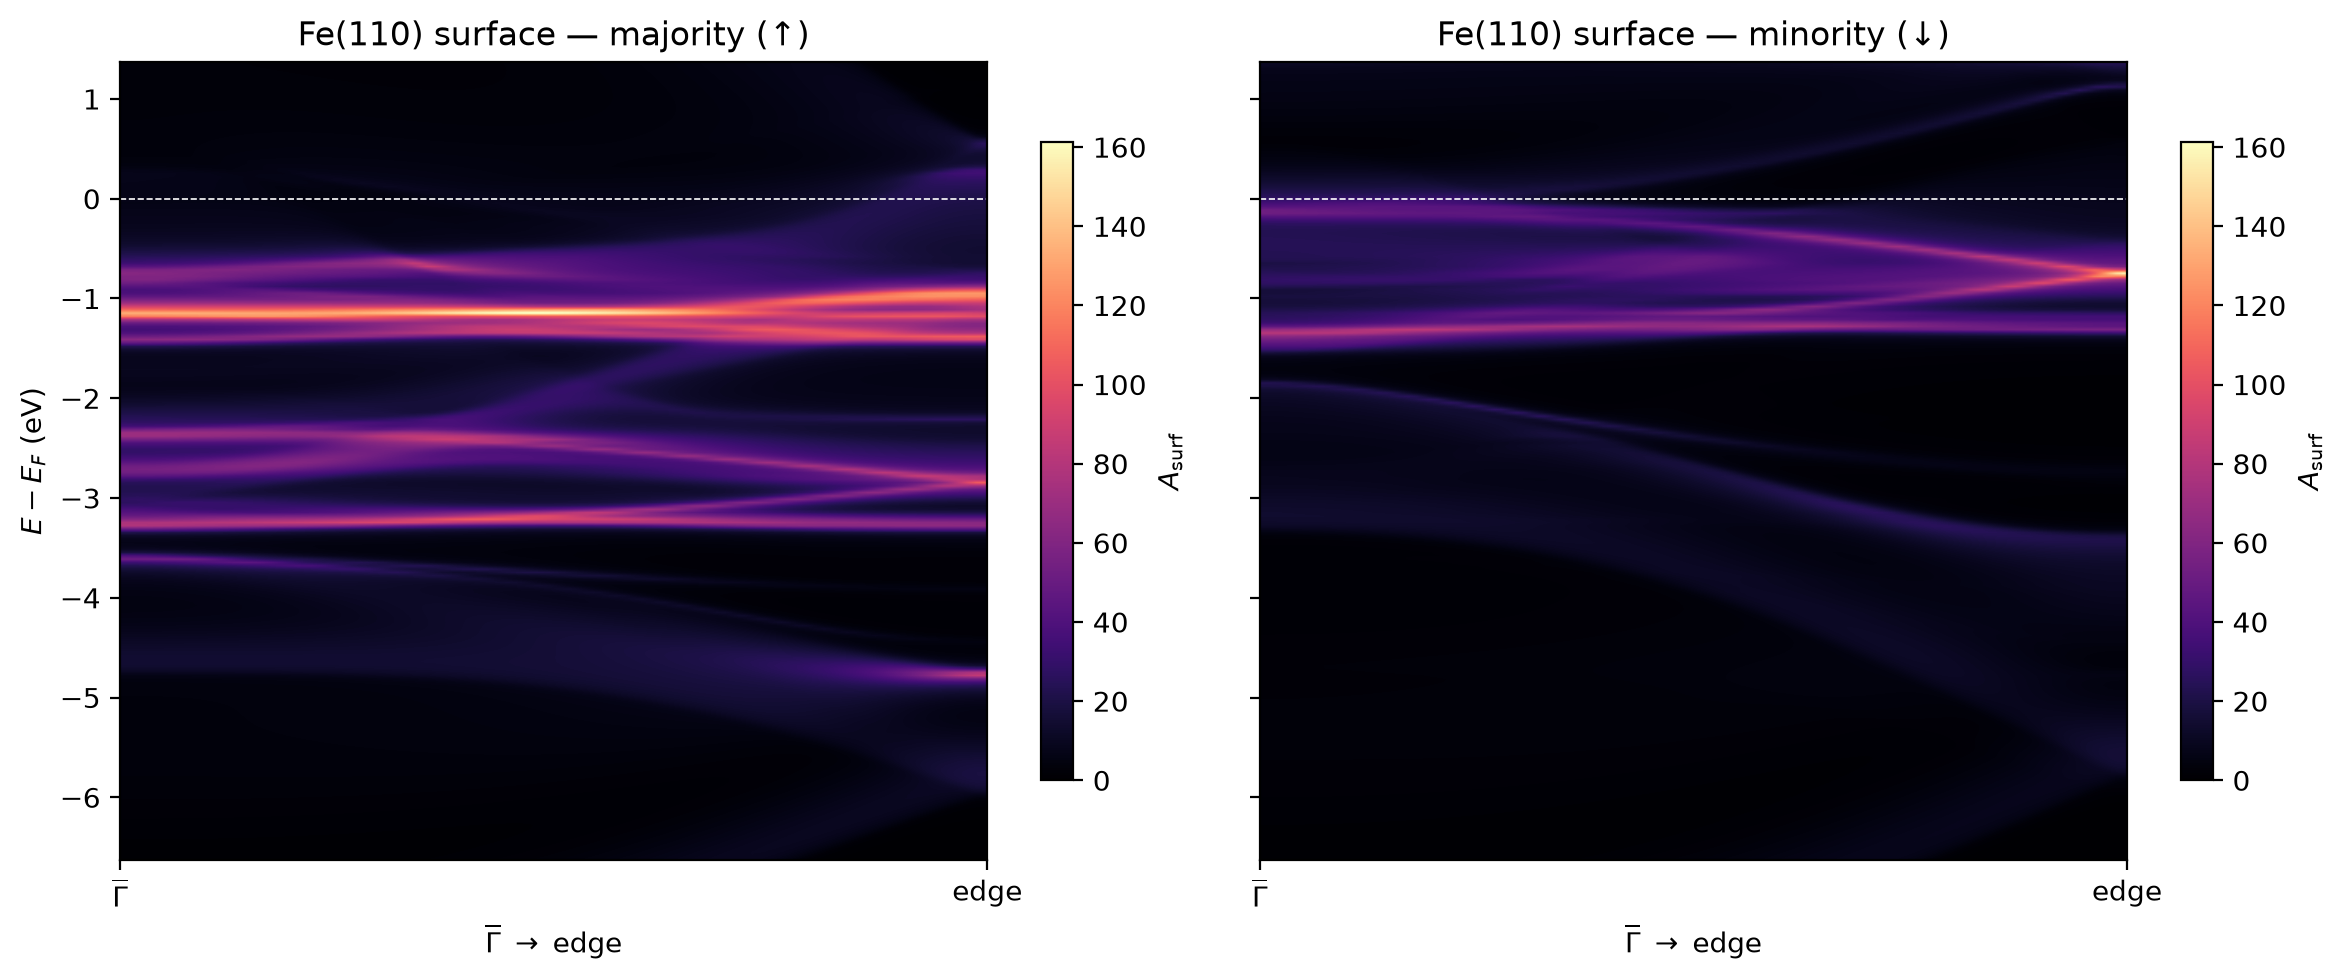

In [5]:
E = energies / EV_TO_HARTREE - E_FERMI
ext = [0, 1, E[0], E[-1]]
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=200)
for a, A, t in [(ax[0], sf.A_up, 'majority (↑)'), (ax[1], sf.A_dn, 'minority (↓)')]:
    im = a.imshow(A.T, origin='lower', aspect='auto', extent=ext, cmap='magma',
                  interpolation='bilinear',
                  vmin=0, vmax=np.percentile(sf.A_surface, 99.5))
    a.set_title('Fe(110) surface — ' + t)
    a.set_xlabel(r'$\overline{\Gamma}\ \to$ edge'); a.set_xticks([0, 1])
    a.set_xticklabels([r'$\overline{\Gamma}$', 'edge'])
    a.axhline(0.0, color='w', lw=0.6, ls='--')   # E_F
    fig.colorbar(im, ax=a, shrink=0.8, label=r'$A_\mathrm{surf}$')
ax[0].set_ylabel(r'$E - E_F$ (eV)')
fig.tight_layout()

The two channels differ because the exchange-split Fe d-bands sit at different energies for ↑ and ↓ — the surface states inherit that spin splitting. Increase `MP_GRID` (denser DFT/Wannier mesh) for sharper surface bands.